
![glovo][def]


[def]: docs/images/00-glovo-banner.jpg

# Introduction

This project analyzes one week of Glovo food-delivery operations in Glovalia with the goal of identifying the operational drivers of late deliveries and proposing a practical plan to improve the performance of the food-delivery service.

The business question is straightforward: how can the operation increase the share of food orders completed within 45 minutes? To answer that, the analysis explores order timing, courier reassignment patterns, transport mode, order volume by day and hour, and key service bottlenecks.

The dataset captures core order and fulfillment attributes, including:

- `store_address_id`: the store associated with the order
- `courier_id`: the last courier assigned to the order
- `vertical`: the order category or business vertical
- `transport`: the courier vehicle type used for the final assignment
- `number_of_assignments`: the number of courier reassignment attempts needed to complete the order
- `total_real_distance`: the distance covered by the courier during fulfillment

A key operational KPI is the percentage of food orders delivered within 45 minutes. Delivery time is shaped by several components, including:

- time to assign the order to a courier
- time for the courier to start the order
- time from the courier start until pickup
- waiting time at pickup
- time to travel from the store to the customer
- waiting time in the delivery area

The objective of the analysis is to translate operational signals from the data into a 4-week improvement plan that moves the business toward the target of delivering at least 85% of food orders within 45 minutes.

# Executive Summary

The analysis suggests that the main operational bottlenecks are concentrated around reassignment efficiency, pickup coordination, and time-of-day demand pressure.

- **Reassignments strongly increase delivery time:** average delivery time rises sharply as the number of courier reassignments increases.
- **Peak demand periods matter:** specific days and hours show higher order volume and longer delivery times, indicating operational strain during busy periods.
- **Pickup waiting is a likely friction point:** the biggest delay appears to occur at the pickup step, which suggests store-side readiness and courier arrival alignment are important levers.
- **Transport mode affects performance:** cars are associated with the longest delivery times, while motorbikes are linked to faster fulfillment and should be prioritized in peak windows.
- **Distance matters, but not enough on its own:** there is some relationship between distance traveled and delivery time, although additional investigation would be needed to separate distance-driven delay from coordination delays.

# Recommended 4-Week Improvement Plan

**TARGET:** Reach 85% of total food deliveries in 45 minutes or less.

**Week 1: Reducing Reassignments and Optimizing Courier Assignment**

Focus: Implement strategies to minimize reassignments, which are significantly increasing delivery times.

Actions:
- Refine the courier matching algorithm to reduce the likelihood of reassignments.

- Introduce incentives for couriers to accept and complete orders.

- Start a performance-based reward system for timely deliveries.

Expected Outcome: Reduced average delivery time by decreasing reassignments.

**Week 2: Implementing Dynamic Pricing and Slot Optimization**

Focus: Adjust pricing and courier availability during peak hours.

Actions:

- Introduce dynamic pricing to encourage orders during off-peak hours.

- Increase courier availability during peak periods (Wednesday, Saturday, Tuesday evenings).

Expected Outcome: More even distribution of orders throughout the week, reducing pressure during peak times.

**Week 3: Encouraging Efficient Modes of Transportation**

Focus: Prioritize faster transportation modes.

Actions:

- Discourage the use of cars for deliveries due to longer delivery times.

- Promote the use of motorbikes, especially during peak hours.

- Expected Outcome: Improved delivery efficiency by leveraging faster transport modes.

**Week 4: Enhancing Waiting Time Management**

Focus: Reduce waiting times, especially at pickup points.

Actions:

- Work with partner stores to optimize food preparation times.

- Implement a real-time notification system for couriers to align their arrival with order readiness.

- Expected Outcome: Reduced overall delivery time by minimizing courier waiting periods.

**Continuous Monitoring and Adjustment**
Throughout the 4-week period, it's crucial to:

- Monitor KPIs like the percentage of deliveries under 45 minutes, courier efficiency, and customer satisfaction.

- Analyze the cancellation rates and reasons behind any cancellations.

- Adjust the strategies based on real-time data and feedback.

**Pilot and Scale**

Simulate the effect of implemented changes. 

Gradually expand the strategies across the city as they prove effective.


Additional resources:

Delivery time data: [link](https://docs.google.com/spreadsheets/d/1HA2-ONKXVannuKqJd4Dfa7NG4fGFRbYYaowgK4hc3Vg/edit#gid=284922136)

# Exploring the data

In [115]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load your dataset into a DataFrame
data1 = pd.read_excel("DATA_1_BC.xlsx")

# Print the number of rows and columns
print("Number of rows and columns:", data1.shape)

# Remove columns with names starting with 'Unnamed'
data1 = data1.loc[:, ~data1.columns.str.startswith('Unnamed')]

# Normalize known datetime fields once so downstream analysis remains consistent
for column in [
    "activation_time_local",
    "last_courier_assigned_time",
    "courier_started_order_local",
    "courier_enters_pickup_time_local",
    "pickup_time_local",
    "courier_enters_delivery_point_time_local",
    "termination_time",
]:
    if column in data1.columns:
        data1[column] = pd.to_datetime(data1[column], errors="coerce")

# Small helper to keep repeated delivery-time boxplots consistent and cleaner

def plot_delivery_boxplot(x_col, title, xlabel, palette=None, order=None, y_series=None):
    if y_series is None:
        y_series = delivery_time_m

    plt.figure(figsize=(12, 6))
    kwargs = {
        "x": x_col,
        "y": y_series,
        "data": data1,
        "hue": x_col,
        "dodge": False,
        "legend": False,
    }
    if palette is not None:
        kwargs["palette"] = palette
    if order is not None:
        kwargs["order"] = order

    sns.boxplot(**kwargs)
    plt.title(title)
    plt.ylabel("Delivery Time (minutes)")
    plt.xlabel(xlabel)
    plt.ylim(0, 120)
    plt.show()

# Print out the first five rows
data1.head()

Number of rows and columns: (2471, 25)


,id,final_status,store_address_id,customer_id,courier_id,vertical,is_food,transport,number_of_assignments,total_real_distance,activation_time_local,last_courier_assigned_time,courier_started_order_local,courier_enters_pickup_time_local,pickup_time_local,courier_enters_delivery_point_time_local,termination_time
0,53134335,DeliveredStatus,85260.0,18579597,20153483,WALL - Partner,True,BICYCLE,1,6.029,2019-07-13 13:04:44,2019-07-13 13:05:32,2019-07-13 13:06:49,2019-07-13 13:09:13,2019-07-13 13:28:45,2019-07-13 13:46:58,2019-07-13 13:59:49
1,53009545,DeliveredStatus,23517.0,11871195,20153483,WALL - Partner,True,BICYCLE,1,3.998,2019-07-12 20:06:29,2019-07-12 20:10:42,2019-07-12 20:11:02,2019-07-12 20:16:05,2019-07-12 20:23:07,2019-07-12 20:37:53,2019-07-12 20:43:01
2,53129297,DeliveredStatus,18300.0,1053786,20153483,WALL - Partner,True,BICYCLE,1,5.309,2019-07-13 12:14:58,2019-07-13 12:15:44,2019-07-13 12:23:40,2019-07-13 12:45:16,2019-07-13 12:50:09,2019-07-13 12:55:16,2019-07-13 12:59:23
3,53235752,CanceledStatus,85260.0,20466508,20153483,WALL - Partner,True,BICYCLE,1,6.429,2019-07-13 21:55:58,2019-07-13 22:24:58,2019-07-13 22:24:58,NaT,NaT,NaT,2019-07-13 22:25:15
4,53002671,DeliveredStatus,15912.0,16549489,20153483,WALL - Partner,True,BICYCLE,1,3.442,2019-07-12 19:40:13,2019-07-12 19:41:14,2019-07-12 19:42:34,2019-07-12 19:46:28,2019-07-12 19:56:59,2019-07-12 20:07:08,2019-07-12 20:10:37


In [116]:
# Display information about the dataframe 'data1'
data1.info()

<class 'pandas.DataFrame'>
RangeIndex: 2471 entries, 0 to 2470
Data columns (total 17 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   id                                        2471 non-null   int64         
 1   final_status                              2471 non-null   str           
 2   store_address_id                          2440 non-null   float64       
 3   customer_id                               2471 non-null   int64         
 4   courier_id                                2471 non-null   int64         
 5   vertical                                  2471 non-null   str           
 6   is_food                                   2471 non-null   bool          
 7   transport                                 2471 non-null   str           
 8   number_of_assignments                     2471 non-null   int64         
 9   total_real_distance                      

## 1. Checking for missing values

In [117]:
# Check for missing values in the 'data1' dataframe
data1.isna().sum()

id                                           0
final_status                                 0
store_address_id                            31
customer_id                                  0
courier_id                                   0
vertical                                     0
is_food                                      0
transport                                    0
number_of_assignments                        0
total_real_distance                          0
activation_time_local                        0
last_courier_assigned_time                   0
courier_started_order_local                  0
courier_enters_pickup_time_local            61
pickup_time_local                           61
courier_enters_delivery_point_time_local    67
termination_time                             0
dtype: int64

In [118]:
# Fill missing values in the "store_address_id" column with 0
data1['store_address_id'] = data1['store_address_id'].fillna(0)

In [119]:
print("Number of unique courier:",data1["courier_id"].nunique())
print("Number of unique stores:",data1["store_address_id"].nunique())

Number of unique courier: 83
Number of unique stores: 68


## 2. Exploring the canceled deliveries

In [120]:
# Filter the rows in data1 which have a canceled status
not_delivered = data1[data1["final_status"]=="CanceledStatus"]

# Display the filtered dataframe
display(not_delivered)

# Filter the rows in not_delivered that are duplicates
duplicates = not_delivered[not_delivered.duplicated()]

# Check if there are any duplicates
if duplicates.empty:
    print("No duplicates")

# Display descriptive statistics for the "number_of_assignments" and "total_real_distance" columns in not_delivered
not_delivered[["number_of_assignments", "total_real_distance"]].describe().round(2)

,id,final_status,store_address_id,customer_id,courier_id,vertical,is_food,transport,number_of_assignments,total_real_distance,activation_time_local,last_courier_assigned_time,courier_started_order_local,courier_enters_pickup_time_local,pickup_time_local,courier_enters_delivery_point_time_local,termination_time
3,53235752,CanceledStatus,85260.0,20466508,20153483,WALL - Partner,True,BICYCLE,1,6.429,2019-07-13 21:55:58,2019-07-13 22:24:58,2019-07-13 22:24:58,NaT,NaT,NaT,2019-07-13 22:25:15
10,52634695,CanceledStatus,18300.0,2274369,14547224,WALL - Partner,True,BICYCLE,1,4.298,2019-07-10 15:12:27,2019-07-10 15:13:04,2019-07-10 15:13:34,2019-07-10 15:26:38,2019-07-10 15:45:38,NaT,2019-07-10 16:10:24
158,52569774,CanceledStatus,50845.0,1908784,14917583,WALL - Partner,True,BICYCLE,1,5.928,2019-07-10 00:06:25,2019-07-10 00:07:00,2019-07-10 00:07:51,NaT,NaT,NaT,2019-07-10 00:25:36
214,52693818,CanceledStatus,18296.0,10330603,13762181,WALL - Partner,True,CAR,3,9.728,2019-07-10 21:08:40,2019-07-10 22:10:05,2019-07-10 22:10:05,NaT,NaT,NaT,2019-07-10 22:12:21
321,52486253,CanceledStatus,16697.0,13220340,4055620,WALL - Partner,True,MOTORBIKE,2,3.788,2019-07-09 18:41:01,2019-07-09 19:26:17,2019-07-09 19:26:17,NaT,NaT,NaT,2019-07-09 19:30:02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2409,52866951,CanceledStatus,18300.0,11628788,15058366,WALL - Partner,True,BICYCLE,1,4.081,2019-07-11 21:57:34,2019-07-11 21:58:25,2019-07-11 21:58:53,2019-07-11 22:08:04,2019-07-11 22:34:16,2019-07-11 22:52:47,2019-07-11 23:14:31
2444,52770259,CanceledStatus,17471.0,1001032,9558769,WALL - Partner,True,MOTORBIKE,1,5.141,2019-07-11 12:30:51,2019-07-11 12:31:20,2019-07-11 12:31:31,NaT,NaT,NaT,2019-07-11 12:38:08
2455,53147537,CanceledStatus,0.0,20539057,19090546,QUIERO,False,CAR,1,17.887,2019-07-13 14:28:31,2019-07-13 14:28:58,2019-07-13 14:29:18,NaT,NaT,NaT,2019-07-13 14:42:46
2460,53131903,CanceledStatus,30640.0,4730315,19090546,WALL - Partner,True,CAR,1,6.294,2019-07-13 12:43:01,2019-07-13 12:54:22,2019-07-13 12:54:35,NaT,NaT,NaT,2019-07-13 13:08:15


No duplicates


,number_of_assignments,total_real_distance
count,82.00,82.00
mean,1.46,5.97
std,0.85,3.36
min,1.00,1.10
25%,1.00,3.88
50%,1.00,5.16
75%,2.00,7.46
max,5.00,17.89


In [121]:
# Display descriptive statistics for the "number_of_assignments" and "total_real_distance" columns in data1
data1[["number_of_assignments", "total_real_distance"]].describe().round(2)

,number_of_assignments,total_real_distance
count,2471.00,2471.00
mean,1.17,5.05
std,0.48,2.48
min,1.00,0.71
25%,1.00,3.34
50%,1.00,4.56
75%,1.00,6.13
max,6.00,19.79


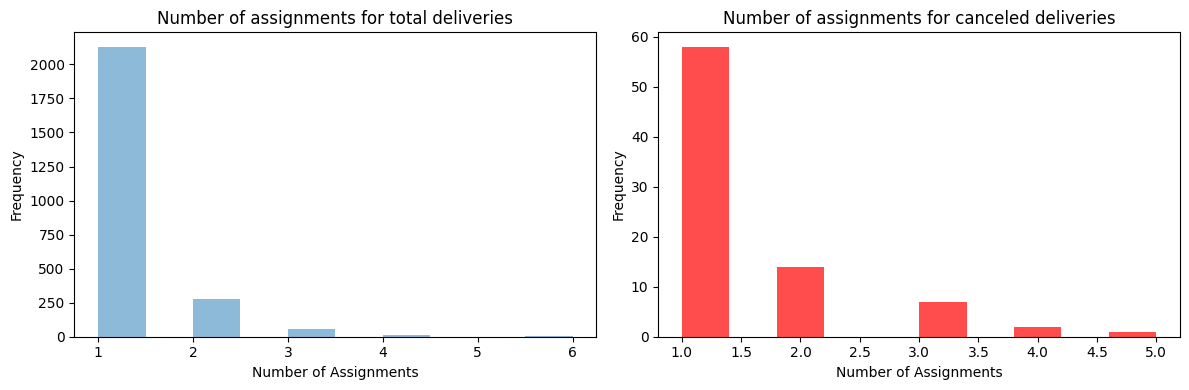

In [122]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot a histogram of the "number_of_assignments" column in data1
ax1.hist(data1["number_of_assignments"], bins=10, alpha=0.5)
ax1.set_title("Number of assignments for total deliveries")
ax1.set_xlabel("Number of Assignments")
ax1.set_ylabel("Frequency")

# Plot a histogram of the "number_of_assignments" column in not_delivered
ax2.hist(not_delivered["number_of_assignments"], bins=10, alpha=0.7, color="red")
ax2.set_title("Number of assignments for canceled deliveries")
ax2.set_xlabel("Number of Assignments")
ax2.set_ylabel("Frequency")

# Adjust the layout of the subplots
plt.tight_layout()

# Display the plot
plt.show()

- The cancelled deliveries have a higher reassignment average of 1.46 compared to 1.17 total average, suggesting that `higher number of reassingments` might lead to a canceled order. 

![canceled_time][def]


[def]: docs/images/09-canceled-orders-detail.png

- Upon examining the canceled deliveries data further, it becomes evident that a significant portion of the orders are being canceled due to the `extended duration between activation and pickup`, often spanning several hours.
- Further analysis is advised to identify and understand the factors contributing to these delays.

In [123]:
# Group the data by store_address_id and count the number of CanceledStatus
cancel_store = data1[data1["final_status"]=="CanceledStatus"].groupby("store_address_id").size()

# Check if cancel_store is empty
if cancel_store.empty:
    print("No canceled orders found.")
else:
    # Find the top 3 stores with the highest number of canceled orders
    top_cancel_stores = cancel_store.nlargest(3)

    # Print the top 3 stores and their respective number of canceled orders
    for store, count in top_cancel_stores.items():
        print("Store:", store)
        print("Number of canceled orders:", count)

Store: 18300.0
Number of canceled orders: 18
Store: 30640.0
Number of canceled orders: 14
Store: 0.0
Number of canceled orders: 11


In [124]:
# Group the data by courier_id and count the number of CanceledStatus
cancel_courier = data1[data1["final_status"]=="CanceledStatus"].groupby("courier_id").size()

# Find the top 3 couriers with the highest number of canceled deliveries
top_cancel_couriers = cancel_courier.nlargest(3)

# Print the top 3 couriers and their respective number of canceled deliveries
for courier, count in top_cancel_couriers.items():
    print("Courier:", courier)
    print("Number of canceled orders:", count)

Courier: 16327386
Number of canceled orders: 6
Courier: 6212245
Number of canceled orders: 5
Courier: 2234219
Number of canceled orders: 4


In [125]:

group_delivered = data1.groupby("final_status")["final_status"].count()
print(group_delivered)
canceled_orders = data1[data1["final_status"]=="CanceledStatus"].shape[0]/data1.shape[0]
print("canceled_orders:",round(canceled_orders*100,2),"%")


final_status
CanceledStatus       82
DeliveredStatus    2389
Name: final_status, dtype: int64
canceled_orders: 3.32 %


- As there is no KPI for canceled orders, I will assume that a `cancel rate below 5%` is deemed acceptable and within expected parameters.
- The store address with `ID 18300` has the highest number of cancellations (18) 
- Togheter stores ID 18300 and ID 30640  make up `39% of all canceled deliveries`. 
- Stores with no id show as the third in number of canceled deliveries. 
- The courier with ID `16327386` has the highest number of cancellations (6). 
- If numbers repeat over the following weeks, both, the stores and the couriers should be contacted.

## 3. Cleaning the data

In [126]:
# Fill missing numeric values without touching datetime columns
numeric_cols = data1.select_dtypes(include=['number', 'boolean']).columns
data1[numeric_cols] = data1[numeric_cols].fillna(0)

# Check for missing values in the 'data1' dataframe
data1.isna().sum()

id                                           0
final_status                                 0
store_address_id                             0
customer_id                                  0
courier_id                                   0
vertical                                     0
is_food                                      0
transport                                    0
number_of_assignments                        0
total_real_distance                          0
activation_time_local                        0
last_courier_assigned_time                   0
courier_started_order_local                  0
courier_enters_pickup_time_local            61
pickup_time_local                           61
courier_enters_delivery_point_time_local    67
termination_time                             0
dtype: int64

In [127]:
# Delete rows with final_status equal to "CanceledStatus" from the data1 dataframe
data1 = data1[data1["final_status"] != "CanceledStatus"]

# Filter rows where is_food is True
data1 = data1[data1["is_food"] == True]


- Given that the case's objective is specifically focused on achieving food deliveries within 45 minutes, I have excluded all non-food deliveries from the subsequent analysis.
- Considering that canceled deliveries cannot be categorized as either delivered under or above 45 minutes, I have excluded those orders from the analysis.


## 4. Food deliveries under and above 45 minutes

In [128]:
# Calculate the delivery time by subtracting the activation time from the termination time
data1["delivery_time"] = pd.to_datetime(data1["termination_time"]) - pd.to_datetime(data1["activation_time_local"])

# Drop negative values from delivery_time
data1["delivery_time"] = data1["delivery_time"][data1["delivery_time"] >= pd.Timedelta(0)]

# Check how many deliveries were completed within 45 minutes
delivery_time_45 = data1["delivery_time"] <= pd.Timedelta(minutes=45)

delivery_time_45o = data1["delivery_time"] > pd.Timedelta(minutes=45)

# Print the number of deliveries completed within 45 minutes
print("Number of deliveries under 45 minutes:", delivery_time_45.sum())

print("Number of deliveries over 45 minutes:", delivery_time_45o.sum())

# Calculate the delivery KPI by dividing the number of deliveries completed within 45 minutes by the total number of deliveries
delivery_kpi = delivery_time_45.sum() / data1["delivery_time"].count()

# Print the percentage of actual deliveries completed within 45 minutes
print("Actual deliveries under 45 min:", round(delivery_kpi * 100, 2), "%")

# Print the target percentage of deliveries to be completed within 45 minutes
print("Target deliveries under 45 min: 85.00%")
print("Difference:",85 -round(delivery_kpi * 100, 1), "%")

Number of deliveries under 45 minutes: 1706
Number of deliveries over 45 minutes: 616
Actual deliveries under 45 min: 73.47 %
Target deliveries under 45 min: 85.00%
Difference: 11.5 %


The analysis of delivery times reveals the following key metrics:

- Number of all successful deliveries: 2389

- Number of all food deliveries: 2322

- Number of deliveries under 45 minutes: 1706

- Number of deliveries over 45 minutes: 616

- Actual deliveries under 45 min: 73.47 %

- Target deliveries under 45 min: 85.00%

- Difference: -11.53%

## 4.1 Average delivery time distribution

Average time from activation to delivery, total: 37.83
Average time from activation to delivery < 45 min: 29.73
Difference: 8.099999999999998


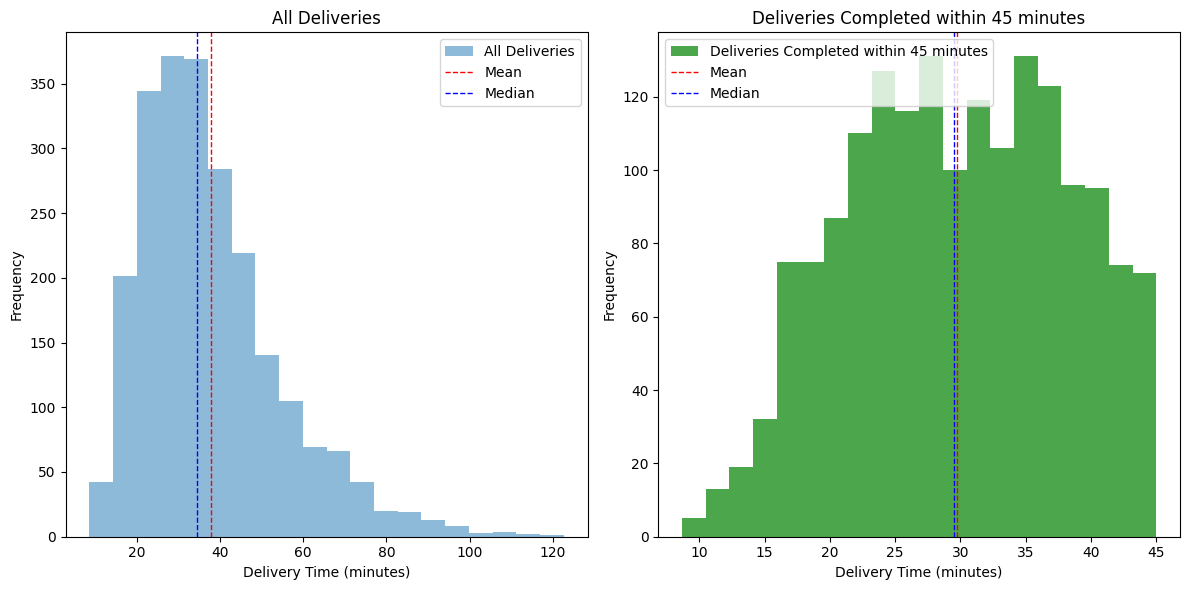

In [129]:
# Convert delivery_time to minutes as delivery_time_m
delivery_time_m = data1["delivery_time"].dt.total_seconds() / 60

# Calculate the minimum, maximum, and average delivery time
delivery_min = round(delivery_time_m.min(), 2)  
delivery_max = round(delivery_time_m.max(), 2)  
delivery_avg = round(delivery_time_m.mean(), 2)  
delivery_med = round(delivery_time_m.median(), 2)  
delivery_time_45m = delivery_time_m[delivery_time_m <= 45]

delivery_avg45 = round(delivery_time_45m.mean(), 2)  
delivery_med45 = round(delivery_time_45m.median(), 2)  

# Print the minimum, maximum, and average delivery time
print("Average time from activation to delivery, total:", round(delivery_avg, 2))
# Print the  average delivery time within 45 minutes
print("Average time from activation to delivery < 45 min:",round(delivery_avg45, 2))
print("Difference:",round(delivery_avg, 2)-round(delivery_avg45, 2))

# Plot the histogram of delivery_time_m with mean and median
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(delivery_time_m, bins=20, alpha=0.5, label="All Deliveries")
plt.axvline(delivery_avg, color='red', linestyle='dashed', linewidth=1, label='Mean')
plt.axvline(delivery_med, color='blue', linestyle='dashed', linewidth=1, label='Median')
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Frequency")
plt.title("All Deliveries")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(delivery_time_m[delivery_time_m <= 45], bins=20, alpha=0.7, color="green", label="Deliveries Completed within 45 minutes")
plt.axvline(delivery_avg45, color='red', linestyle='dashed', linewidth=1, label='Mean')
plt.axvline(delivery_med45, color='blue', linestyle='dashed', linewidth=1, label='Median')
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Frequency")
plt.title("Deliveries Completed within 45 minutes")
plt.legend()

plt.tight_layout()
plt.show()

In [130]:

# Filter records where delivery_time is above 45 minutes
filtered_data = data1[data1['delivery_time'] > pd.Timedelta(minutes=45)]

- Here I've split the data into two gruops - deliveris that where made under 45 minutes and deliveries that took more then 45 minutes on average to complete, to see the similarities and differences between them.
What we can get from this data is the following:
- Average time from activation to delivery, total: 37.83
- Average time from activation to delivery < 45 min: 29.73
Difference: 8 minutes

- If courier average delivery time exceeds 30 minutes on average, they are very likely in the above 45 minutes group.

## 5. Average delivery time by vertical type

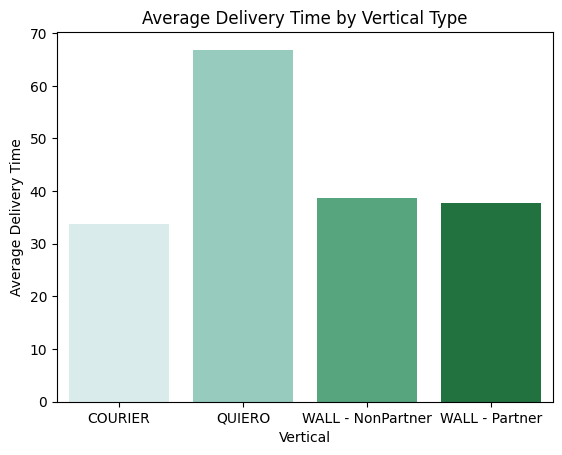

In [153]:
# Calculate the average delivery time by vertical type
partnership = data1.groupby("vertical")["delivery_time"].mean()

# Create a bar plot to visualize the average delivery time by vertical type
sns.barplot(
    x=partnership.index,
    y=partnership.values,
    hue=partnership.index,
    palette='BuGn',
    dodge=False,
    legend=False
)

# Set the x-axis label
plt.xlabel("Vertical")

# Set the y-axis label
plt.ylabel("Average Delivery Time")

# Set the title of the plot
plt.title("Average Delivery Time by Vertical Type")

# Display the plot
plt.show()

- Courier and Quiero had only one food delivery in the data provided so they are not statisticly significat for the analysis. 
- Quiero orders are mostly non-food deliveries.
- The data indicates that, regardless of the partner category (WALL - Partner, WALL - NonPartner), delivery times remain similar.
- This suggests that the nature of the **partnership does not have a significant impact on the average time** it takes to complete a delivery. 


## 6. Average delivery time by day of the week

In [132]:
# Extract the day name from the termination_time column
data1["day"] = data1["termination_time"].dt.day_name()

# Group by day_name and calculate the mean delivery_time
average_delivery_time = data1.groupby("day")["delivery_time"].mean()

# Sort the average_delivery_time in descending order
average_delivery_time = average_delivery_time.sort_values(ascending=False)

# Group by day_name and calculate the count of delivery_time
order_count_by_day = data1.groupby("day")["delivery_time"].count().sort_values(ascending=False)

# Print the average_delivery_time
print(average_delivery_time)

# Print the order_count_by_day
print(order_count_by_day)

# Extract the day name from the termination_time column
filtered_data["day"] = filtered_data["termination_time"].dt.day_name()

# Group by day_name and calculate the mean delivery_time for filtered_data
average_delivery_time_filtered = filtered_data.groupby("day")["delivery_time"].mean()

# Sort the average_delivery_time_filtered in descending order
average_delivery_time_filtered = average_delivery_time_filtered.sort_values(ascending=False)

# Print the average_delivery_time_filtered
print(average_delivery_time_filtered)

# Print a blank line
print()

#order_count_by_day.plot(kind="bar",color="royalblue", alpha=0.8)
#plt.xlabel("Day of the week")
#plt.ylabel("Orders")
#plt.show()


day
Wednesday   0 days 00:47:42.130081
Saturday    0 days 00:42:46.684454
Tuesday     0 days 00:40:27.696969
Friday      0 days 00:34:04.695652
Thursday    0 days 00:33:32.711340
Monday      0 days 00:32:26.017857
Sunday      0 days 00:30:59.312328
Name: delivery_time, dtype: timedelta64[us]
day
Saturday     431
Wednesday    369
Sunday       365
Friday       322
Thursday     291
Monday       280
Tuesday      264
Name: delivery_time, dtype: int64
day
Wednesday   0 days 01:04:18.700564
Saturday    0 days 01:01:31.630303
Tuesday     0 days 01:00:53.775280
Sunday      0 days 00:58:47.204545
Thursday    0 days 00:54:38.108695
Friday      0 days 00:53:31.687500
Monday      0 days 00:53:21.340425
Name: delivery_time, dtype: timedelta64[us]



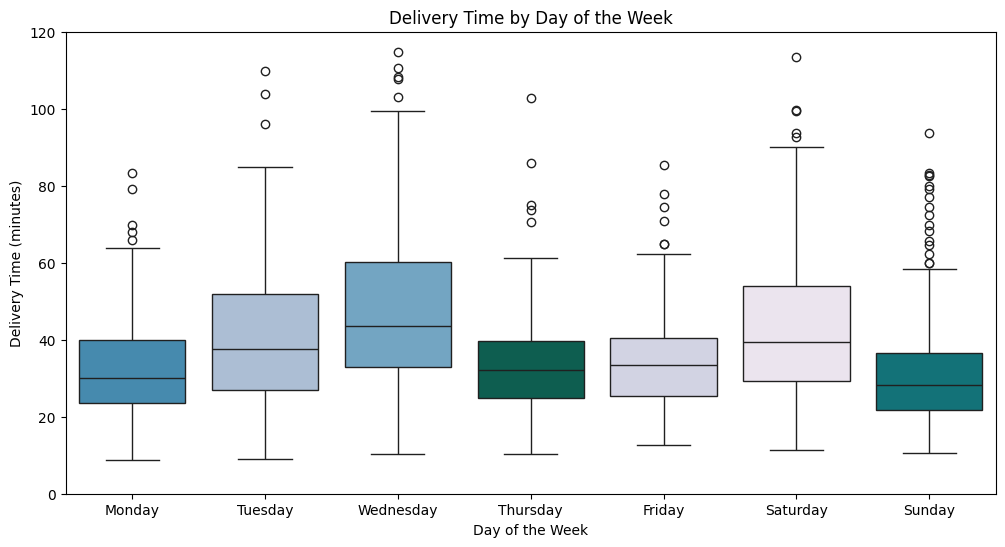

In [133]:
# 6. Day of the Week Analysis
plot_delivery_boxplot(
    x_col='day',
    title='Delivery Time by Day of the Week',
    xlabel='Day of the Week',
    palette='PuBuGn',
    order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

![number_of_orders_days][def]

![weekdays_delivery_time](docs/images/03-delivery-time-by-weekday.png)

[def]: docs/images/06-orders-by-day.png

- `Wednesday, Saturday, and Tuesday` exhibited the **highest mean/median delivery times** during this week (even thought Sunday had the most outliers in total).
- `Saturday, Wednesday and Sunday` recorded the **highest number of orders.**
- Upon examining the filtered data, considering only deliveries completed after 45 minutes, the same pattern persists. The longest mean/median delivery times are consistently observed on Wednesday, Saturday, and Tuesday.


## 7. Average delivery time by hours

hour
21   0 days 00:44:33.763796
22   0 days 00:42:53.036363
20   0 days 00:41:19.719202
17   0 days 00:34:36.950819
10   0 days 00:34:17.176470
11   0 days 00:34:08.843750
19   0 days 00:34:05.683006
13   0 days 00:33:26.945205
12   0 days 00:31:48.692982
16   0 days 00:31:31.196428
18   0 days 00:31:15.689320
15   0 days 00:30:22.700000
14   0 days 00:29:59.305263
23   0 days 00:28:27.564705
0    0 days 00:27:37.318181
Name: delivery_time, dtype: timedelta64[us] hour
20    552
21    453
19    306
22    220
13    146
12    114
18    103
14     95
23     85
17     61
15     60
16     56
11     32
0      22
10     17
Name: id, dtype: int64


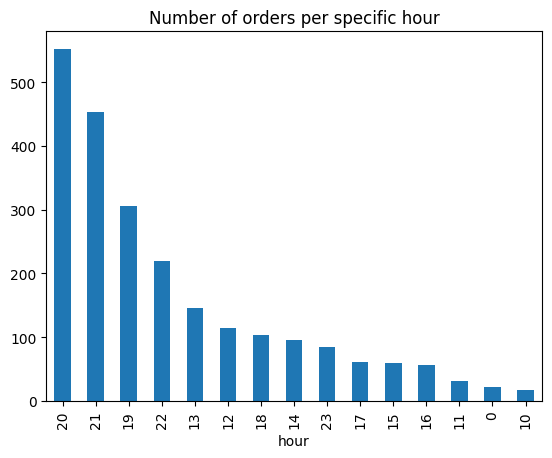

In [134]:
# Extract the hour from the activation_time_local column
data1["hour"] = data1["activation_time_local"].dt.hour

# Group by hour and calculate the mean delivery_time
average_delivery_time_by_hour = data1.groupby("hour")["delivery_time"].mean()

# Sort the average delivery time by hour in descending order
average_delivery_time_by_hour = average_delivery_time_by_hour.sort_values(ascending=False)

# Count the number of orders per hour
order_count_by_hour = data1.groupby("hour")["id"].count().sort_values(ascending=False)

# Print the average delivery time by hour and the number of orders per hour
print(average_delivery_time_by_hour, order_count_by_hour)

# Plot a bar chart to visualize the number of orders per specific hour
order_count_by_hour.plot(kind="bar")
plt.title("Number of orders per specific hour")
plt.show()

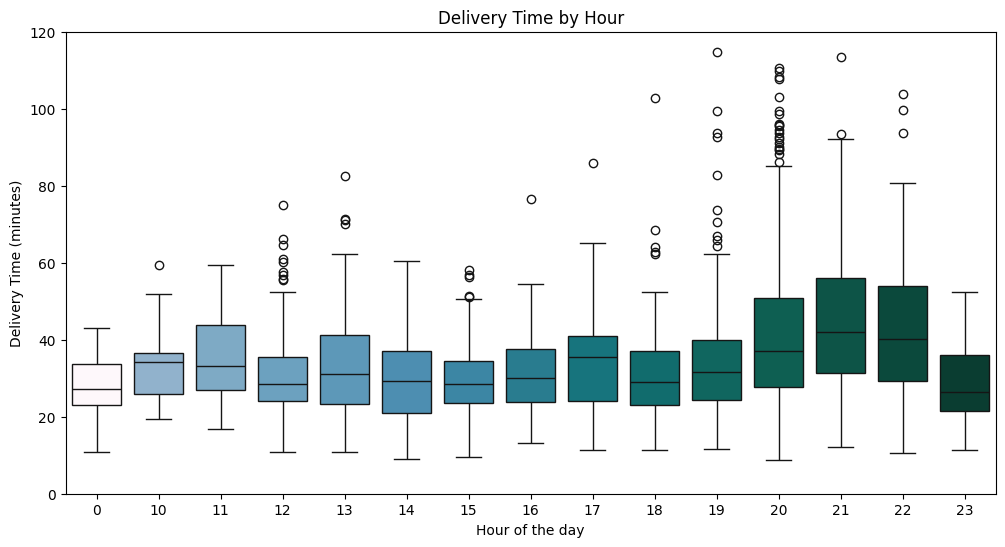

In [135]:
# 7. Peak Hours Analysis
plot_delivery_boxplot(
    x_col='hour',
    title='Delivery Time by Hour',
    xlabel='Hour of the day',
    palette='PuBuGn'
)

![dt_by_hour](docs/images/04-delivery-time-by-hour.png)

![average_delivery_time_by_hour][def]


[def]: docs/images/05-orders-by-hour.png

- The **longest average delivery** time occurs between 20:00 and 23:00. 
- The **peak number of orders** is also observed between 19:00 and 21:00. 

- Drawing from this observation, and assuming this sample data reflects an ongoing trend, **opening more slots for couriers during these hours on Wednesday, Saturday, and Tuesday** or offering discounts for orders outside peak days and hours could potentially lead to a **reduction in the average delivery time**.
- Another approach would be to have a dynamic price which increases the delivery cost (or fee for couriers) in peak hours.

## 8. Average delivery time by transport type

In [136]:
# Calculate the mean delivery time grouped by the number of assignments and transport type
data1.groupby(["number_of_assignments", "transport"])["delivery_time"].mean()

number_of_assignments  transport
1                      BICYCLE     0 days 00:35:55.651340
                       CAR         0 days 00:38:20.945619
                       MOTORBIKE   0 days 00:35:06.839563
2                      BICYCLE     0 days 00:45:40.619047
                       CAR         0 days 00:49:38.377777
                       MOTORBIKE   0 days 00:48:43.922077
3                      BICYCLE     0 days 00:44:51.363636
                       CAR         0 days 01:09:02.294117
                       MOTORBIKE   0 days 00:54:27.111111
4                      BICYCLE     0 days 01:19:30.666666
                       CAR                0 days 01:49:46
                       MOTORBIKE   0 days 01:11:05.666666
6                      BICYCLE     0 days 01:14:52.500000
Name: delivery_time, dtype: timedelta64[us]

In [137]:
# Calculate the mean delivery time for each transport type
transport_count = filtered_data.groupby("transport")["delivery_time"].mean()

# Print the mean delivery time for each transport type
print(transport_count)

# Calculate the mean number of assignments for each transport type
transport_asg = filtered_data.groupby("transport")["number_of_assignments"].mean()

# Print the mean number of assignments for each transport type
print(transport_asg)

# Calculate the mean total real distance for each transport type
transport_dis = filtered_data.groupby("transport")["total_real_distance"].mean()

# Print the mean total real distance for each transport type
print(transport_dis)

transport
BICYCLE     0 days 01:00:11.504761
CAR         0 days 01:02:58.463414
MOTORBIKE   0 days 00:58:34.235955
Name: delivery_time, dtype: timedelta64[us]
transport
BICYCLE      1.295238
CAR          1.447154
MOTORBIKE    1.314607
Name: number_of_assignments, dtype: float64
transport
BICYCLE      4.971029
CAR          7.133463
MOTORBIKE    7.225910
Name: total_real_distance, dtype: float64


In [138]:
# Calculate the count of delivery times grouped by the number of assignments and transport type
data1.groupby(["number_of_assignments", "transport"])["delivery_time"].count()

number_of_assignments  transport
1                      BICYCLE      1044
                       CAR           331
                       MOTORBIKE     642
2                      BICYCLE       126
                       CAR            45
                       MOTORBIKE      77
3                      BICYCLE        22
                       CAR            17
                       MOTORBIKE       9
4                      BICYCLE         3
                       CAR             1
                       MOTORBIKE       3
6                      BICYCLE         2
Name: delivery_time, dtype: int64

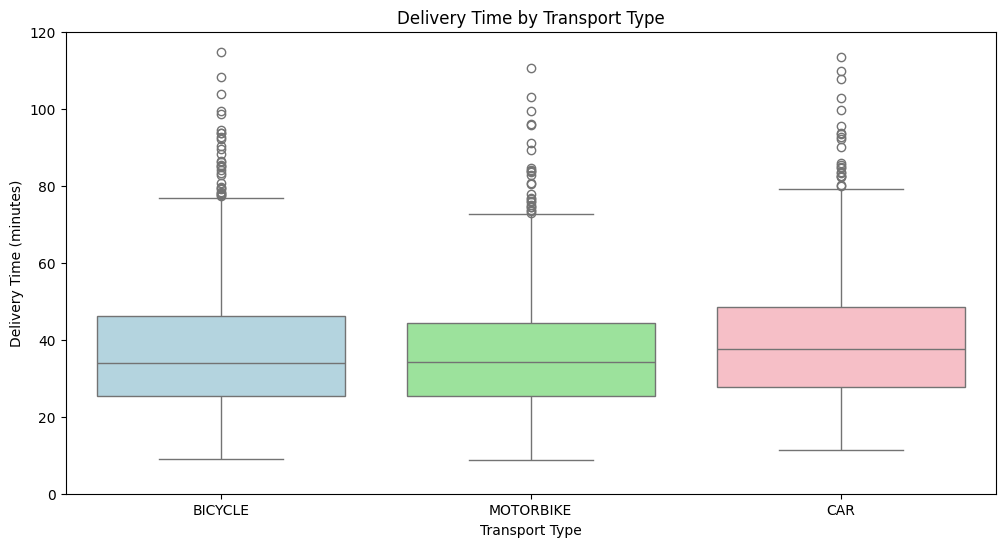

In [139]:
# 3. Transport Type Analysis
plot_delivery_boxplot(
    x_col='transport',
    title='Delivery Time by Transport Type',
    xlabel='Transport Type',
    palette=['lightblue', 'lightgreen', 'lightpink']
)

- **Cars** on average have the **longest delivery time** and **highest average/median reassignment number**.
- Because of that they should be discouraged to use in this town to lower average/median delivery times.
Note:
_It is not possible to conclude why cars have the longest average delivery time from the data presented, and further investigation is advised._

- **Motorbikes** on average have the **lowest delivery time** and **cross the most distance** in the above 45 minutes group.
- Use of motorbikes, especially in peak hours and days should be prioritized to lower average delivery times.

## 9. Average delivery time by assignment number

In [140]:
# Calculate the average delivery time for all deliveries
print("Delivery all")
print(data1.groupby("number_of_assignments")["delivery_time"].mean())

# Calculate the average delivery time for deliveries >45 min
print("\nDelivery >45 min")
print(filtered_data.groupby("number_of_assignments")["delivery_time"].mean())

# Calculate the total count of all delivery times
total_count_all = data1.groupby("number_of_assignments")["delivery_time"].count().sum()

# Calculate the count of deliveries for each number of assignments
delivery_count = data1.groupby("number_of_assignments")["delivery_time"].count()

# Calculate the percentage for each number of assignments
percentage = (delivery_count / total_count_all) * 100
print("\nPercentage for each number of assignments:")
print(percentage)


Delivery all
number_of_assignments
1   0 days 00:36:03.958353
2   0 days 00:47:20.673387
3   0 days 00:55:13.187500
4   0 days 01:20:13.571428
6   0 days 01:14:52.500000
Name: delivery_time, dtype: timedelta64[us]

Delivery >45 min
number_of_assignments
1   0 days 00:58:36.467391
2   0 days 01:02:46.647058
3   0 days 01:09:08.200000
4   0 days 01:35:34.400000
6   0 days 01:14:52.500000
Name: delivery_time, dtype: timedelta64[us]

Percentage for each number of assignments:
number_of_assignments
1    86.864772
2    10.680448
3     2.067183
4     0.301464
6     0.086133
Name: delivery_time, dtype: float64


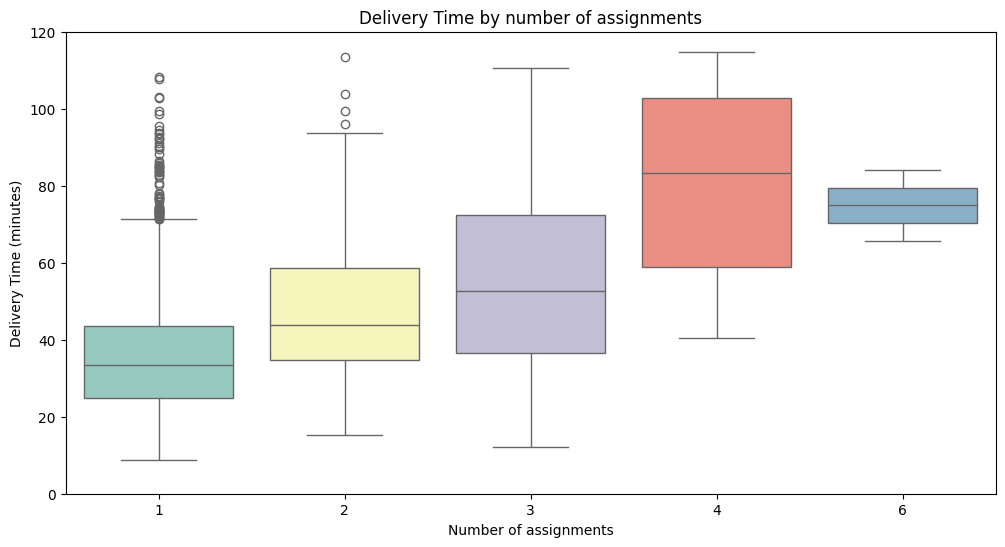

In [141]:
plot_delivery_boxplot(
    x_col='number_of_assignments',
    title='Delivery Time by number of assignments',
    xlabel='Number of assignments',
    palette='Set3'
)

![Reassignments and time to start][def]
- As the reassignment number rises so does the average delivery time.
- There is a **significat increase in average delivery** time from 1 to 2 reassignment, increasing the average delivery time by **23,6%** (from 36 minutes up to 47 minutes!). 
- Examining the data, we can see that there were **318 orders** delivered later than the target time becasuse of reassiginments, constituting **13.3%** of all orders delivered that week.
- By **decreasing the number of assignments** we can increase the number of orders delivered under 45 minutes significantly.

[def]: docs/images/07-reassignments-time-to-start.png

## 10. Relation between distance crossed and delivery time

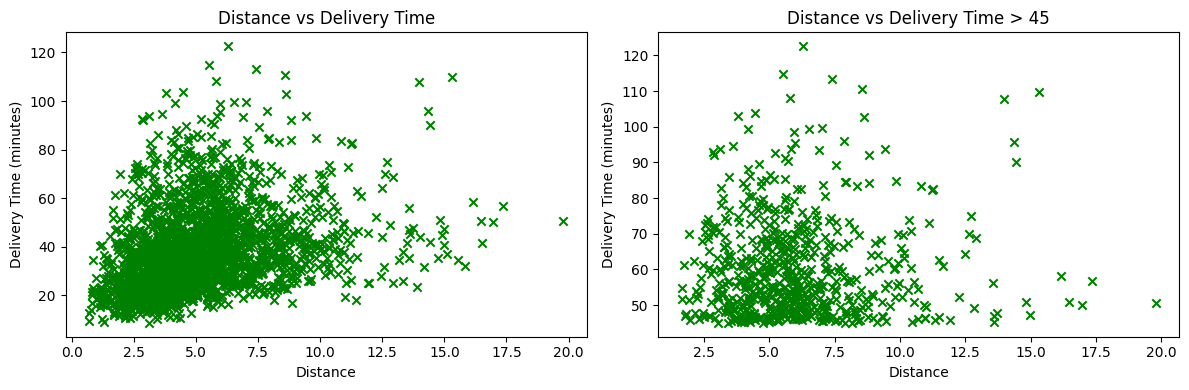

(np.float64(0.3200107532553173), np.float64(0.023546086506817627))

In [142]:
# Convert delivery_time column to minutes
data1["delivery_time"] = data1["delivery_time"].dt.total_seconds() / 60

# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Scatter plot of total_real_distance vs delivery_time_m in the first subplot
axs[0].scatter(data1["total_real_distance"], delivery_time_m, color="green", marker ="x")
axs[0].set_xlabel("Distance")
axs[0].set_ylabel("Delivery Time (minutes)")
axs[0].set_title("Distance vs Delivery Time")

# Scatter plot of total_real_distance vs delivery_time_m for deliveries with time > 45 minutes in the second subplot
axs[1].scatter(filtered_data["total_real_distance"], filtered_data["delivery_time"].dt.total_seconds() / 60, color="green", marker ="x")
axs[1].set_xlabel("Distance")
axs[1].set_ylabel("Delivery Time (minutes)")
axs[1].set_title("Distance vs Delivery Time > 45")

# Adjust the layout and display the plot
plt.tight_layout()
plt.show()

# Calculate the correlation coefficient between total_real_distance and delivery_time_m
correlation1 = np.corrcoef(data1["total_real_distance"], delivery_time_m)[0, 1]

# Calculate the correlation coefficient between total_real_distance and delivery_time_m for deliveries with time > 45 minutes
correlation2 = np.corrcoef(filtered_data["total_real_distance"], filtered_data["delivery_time"].dt.total_seconds() / 60)[0, 1]

correlation1, correlation2

**Relationship Between Total Distance and Delivery Duration:**

- There is a `positive correlation (0.32)` between the total distance and delivery duration, but it's not very strong, indicating other factors also play a significant role in determining delivery times.
- When we analyse only the deliveries over 45 minutes the correlation is even lower (0.23) confirming **distance is not the predominate factor affecting longer delivery times.**
- An idea to test this could be to limit the distance for the courier to travel per order and see if it improves delivery times.

## 11. How different time categories related to delivery times

In [143]:
# Calculate the time difference between the last courier assignment and the activation time
data1["activation_to_assignment"] = pd.to_datetime(data1["last_courier_assigned_time"]) - pd.to_datetime(data1["activation_time_local"])
print(data1["activation_to_assignment"].describe())
data1["activation_to_assignment"] = data1["activation_to_assignment"].dt.total_seconds() / 60


count                      2322
mean     0 days 00:06:13.114125
std      0 days 00:09:35.708458
min             0 days 00:00:02
25%             0 days 00:00:34
50%             0 days 00:01:11
75%      0 days 00:08:53.750000
max             0 days 01:11:38
Name: activation_to_assignment, dtype: object


In [144]:
# Calculate the time difference between the courier starting the order and the activation time
data1["activation_to_start"] = pd.to_datetime(data1["courier_started_order_local"]) - pd.to_datetime(data1["activation_time_local"])
print(data1["activation_to_start"].describe())
data1["activation_to_start"] = data1["activation_to_start"].dt.total_seconds() / 60

count                      2322
mean     0 days 00:08:02.772179
std      0 days 00:11:03.439849
min             0 days 00:00:04
25%      0 days 00:01:00.250000
50%             0 days 00:02:46
75%      0 days 00:10:36.750000
max             0 days 01:15:59
Name: activation_to_start, dtype: object


In [145]:
# Convert columns to DatetimeArray
data1["courier_enters_pickup_time_local"] = pd.to_datetime(data1["courier_enters_pickup_time_local"])
data1["activation_time_local"] = pd.to_datetime(data1["activation_time_local"])

# Calculate the time difference between the courier entering the pickup point and the activation time
data1["activation_to_pick_up"] = data1["courier_enters_pickup_time_local"] - data1["activation_time_local"]
print(data1["activation_to_pick_up"].describe())
data1["activation_to_pick_up"] = data1["activation_to_pick_up"].dt.total_seconds() / 60

count                      2322
mean     0 days 00:09:56.491386
std      0 days 00:11:54.184317
min             0 days 00:00:00
25%             0 days 00:00:25
50%             0 days 00:06:23
75%             0 days 00:14:29
max             0 days 01:29:27
Name: activation_to_pick_up, dtype: object


In [146]:
# Calculate the waiting time at the pickup point
data1["waiting_time"] = pd.to_datetime(data1["pickup_time_local"]) - pd.to_datetime(data1["courier_enters_pickup_time_local"])

# Drop negative values from waiting_time
data1["waiting_time"] = data1["waiting_time"][data1["waiting_time"] >= pd.Timedelta(0)]

# Display descriptive statistics of waiting_time
print(data1["waiting_time"].describe())

# Convert waiting_time to minutes
data1["waiting_time"] = data1["waiting_time"].dt.total_seconds() / 60

count                      2322
mean     0 days 00:15:23.356589
std      0 days 00:12:51.716422
min             0 days 00:00:00
25%             0 days 00:07:11
50%             0 days 00:11:48
75%      0 days 00:18:44.500000
max             0 days 01:27:14
Name: waiting_time, dtype: object


In [147]:
# Calculate the time from store to customer
data1["store_to_customer"] = pd.to_datetime(data1["courier_enters_delivery_point_time_local"]) - pd.to_datetime(data1["pickup_time_local"])

# Display descriptive statistics
print(data1["store_to_customer"].describe())

# Convert to minutes
data1["store_to_customer"] = data1["store_to_customer"].dt.total_seconds()/60

count                      2322
mean     0 days 00:08:08.465546
std      0 days 00:04:05.940665
min             0 days 00:00:03
25%             0 days 00:05:24
50%             0 days 00:07:38
75%      0 days 00:10:03.750000
max             0 days 00:40:01
Name: store_to_customer, dtype: object


In [148]:
# Calculate the time in delivery zone
data1["time_in_delivery_zone"] = pd.to_datetime(data1["termination_time"]) - pd.to_datetime(data1["courier_enters_delivery_point_time_local"])

# Display descriptive statistics
print(data1["time_in_delivery_zone"].describe())

# Convert to minutes
data1["time_in_delivery_zone"] = data1["time_in_delivery_zone"].dt.total_seconds()/60

count                      2322
mean     0 days 00:04:21.670973
std      0 days 00:04:28.035064
min             0 days 00:00:02
25%             0 days 00:02:07
50%      0 days 00:03:20.500000
75%             0 days 00:04:59
max             0 days 01:10:26
Name: time_in_delivery_zone, dtype: object


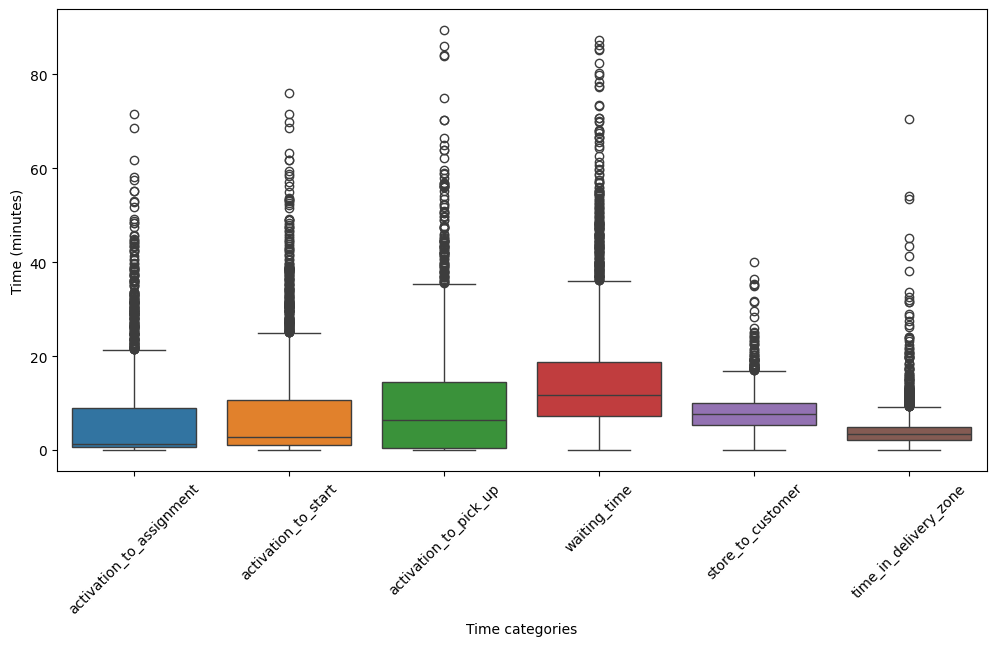

In [149]:
plt.figure(figsize=(12, 6))

# Select the columns for the box plot
columns = ["activation_to_assignment","activation_to_start","activation_to_pick_up", "waiting_time","store_to_customer", "time_in_delivery_zone"]

# Create a box plot using seaborn
sns.boxplot(data=data1[columns])

# Set the title and labels for the plot
plt.xlabel("Time categories")
plt.ylabel("Time (minutes)")

# Rotate x-axis labels for better visibility
plt.xticks(rotation=45)

# Show the plot
plt.show()

- On average, couriers spend most time **waiting to pick up the order**.
- **Reducing the time spent waiting** has the potential to decrease the overall delivery time.

- Achieving this could involve improved monitoring of the time stores require to prepare the food and promptly assigning a courier to handle the delivery.

In [150]:
# Count the outliers in the specified columns
outlier_count = {}

for column in ["activation_to_assignment","activation_to_start","activation_to_pick_up", "waiting_time","store_to_customer", "time_in_delivery_zone","delivery_time"]:
    # Calculate the interquartile range (IQR)
    Q1 = data1[column].quantile(0.25)
    Q3 = data1[column].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define the upper bound for outliers
    upper_bound = Q3 + 1.5 * IQR
    
    # Count the number of outliers above the upper bound
    outliers = data1[data1[column] > upper_bound]
    outlier_count[column] = len(outliers)

# Sort the outlier count dictionary in descending order
outlier_count = dict(sorted(outlier_count.items(), key=lambda x: x[1], reverse=True))

outlier_count

{'activation_to_start': 209,
 'activation_to_assignment': 192,
 'waiting_time': 188,
 'time_in_delivery_zone': 182,
 'activation_to_pick_up': 101,
 'delivery_time': 77,
 'store_to_customer': 68}

- Most outliers are in the following 4 category: (1) activation to start, (2) activation to assignments, (3) waiting time and (4) time in delivery zone, suggesting better courier matching and faster starting could have an positive effect on overall delivery time. 
 

## 12. Simulation



We will conclude this analysis by **simulating the upcoming four weeks**, measuring the percentage of food deliveries completed within 45 minutes. This will be achieved by methodically implementing the 4 actions outlined in our initial four-week plan.

Our focus will be on minimizing reassignments, optimizing courier availability during peak periods, increasing the use of motorbikes during these times, and reducing waiting times at pickup locations.

Each of these changes will be implemented sequentially, week by week, enabling us to effectively measure their individual impact on improving overall delivery times.

In [151]:
np.random.seed(3)

test_data = pd.DataFrame({
    'reassignments': np.random.poisson(0.5, 10000),  # Number of reassignments for each delivery
    'time_of_day': np.random.choice(['morning', 'afternoon', 'evening', 'night'], 10000),  # Time of day for each delivery
    'day_of_week': np.random.choice(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], 10000),  # Day of the week for each delivery
    'weather': np.random.choice(['sunny', 'rainy', 'windy', 'stormy'], 10000),  # Weather condition during each delivery
    'traffic_condition': np.random.choice(['light', 'moderate', 'heavy'], 10000),  # Traffic condition during each delivery
    'transport_mode': np.random.choice(['car', 'motorbike', 'bicycle'], 10000),  # Transport mode used for each delivery
    'waiting_time': np.random.exponential(16,10000),  # Waiting time for each delivery in minutes
    'distance': np.random.uniform(1, 10, 10000),  # Distance traveled for each delivery in km
    'delivery_time': np.random.normal(40, 10, 10000)  # Total delivery time for each delivery in minutes
})

# Initial percentage of deliveries under 45 minutes
initial_performance = delivery_kpi  # Replace 'delivery_kpi' with the actual initial performance metric

last_week_performance = initial_performance

# Print initial performance
print(f"Week 0: {initial_performance:.2%} of deliveries under 45 minutes")

# Function to apply weekly improvements
def apply_weekly_improvements(data, week):
    if week == 1:
        # Reduce the effect of reassignments on delivery time
        data['delivery_time'] -= data['reassignments'] * 5
    elif week == 2:
        # Improve delivery time during evening hours
        data.loc[data['time_of_day'] == 'evening', 'delivery_time'] *= np.random.uniform(0.94, 0.98)
    elif week == 3:
        # Shift from cars to motorbikes - improvement for car deliveries
        data.loc[data['transport_mode'] == 'car', 'delivery_time'] *= np.random.uniform(0.9, 0.95)
    elif week == 4:
        # Reduce the impact of waiting times on delivery time
        data['delivery_time'] -= data['waiting_time'] * np.random.uniform(0.05, 0.1)
    return data

# Apply improvements week by week
for week in range(1, 5):
    test_data = apply_weekly_improvements(test_data, week)
    new_performance = (test_data['delivery_time'] <= 45).mean()
    weekly_improvement = new_performance - last_week_performance
    last_week_performance = new_performance

    print(f"Week {week}: {new_performance:.2%} of deliveries under 45 minutes (Weekly Improvement: {weekly_improvement:.2%})")

# Final evaluation
final_performance = (test_data['delivery_time'] <= 45).mean()
print(f"\nFinal Performance: {final_performance:.2%} of deliveries under 45 minutes")


Week 0: 73.47% of deliveries under 45 minutes


Week 1: 76.43% of deliveries under 45 minutes (Weekly Improvement: 2.96%)
Week 2: 77.78% of deliveries under 45 minutes (Weekly Improvement: 1.35%)
Week 3: 79.63% of deliveries under 45 minutes (Weekly Improvement: 1.85%)
Week 4: 82.97% of deliveries under 45 minutes (Weekly Improvement: 3.34%)

Final Performance: 82.97% of deliveries under 45 minutes


In the simulation we achieved a **9.5% improvement** in the proportion of deliveries completed under 45 minutes, raising them to **82.97%** in four weeks, through the implementation of the previously mentioned changes. 

To further enhance this performance, we will extend our simulation to include Weeks 5 and 6, focusing on reducing cancellation rates and start-to-assignment times to reach the set goal. 

**Week 5: Lowering Cancellation Rates**

- Objective: To decrease the number of canceled orders, which can disrupt the overall delivery flow and impact time efficiency.
- Strategy: Implement proactive measures such as better communication with customers and partners, and predictive analytics to anticipate and prevent potential cancellations.

**Week 6: Reducing Start-to-Assignment Times**
- Objective: To minimize the time taken from order placement to courier assignment.
- Strategy: Optimize the courier assignment algorithm with real-time data processing and AI to quickly match orders with the most suitable couriers.

In [152]:
np.random.seed(3)

test_data = pd.DataFrame({
    'reassignments': np.random.poisson(0.5, 10000),  # Number of reassignments for each delivery
    'time_of_day': np.random.choice(['morning', 'afternoon', 'evening', 'night'], 10000),  # Time of day for each delivery
    'day_of_week': np.random.choice(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], 10000),  # Day of the week for each delivery
    'weather': np.random.choice(['sunny', 'rainy', 'windy', 'stormy'], 10000),  # Weather condition during each delivery
    'traffic_condition': np.random.choice(['light', 'moderate', 'heavy'], 10000),  # Traffic condition during each delivery
    'transport_mode': np.random.choice(['car', 'motorbike', 'bicycle'], 10000),  # Transport mode used for each delivery
    'waiting_time': np.random.exponential(16,10000),  # Waiting time for each delivery in minutes
    'distance': np.random.uniform(1, 10, 10000),  # Distance traveled for each delivery in km
    'delivery_time': np.random.normal(40, 10, 10000)  # Total delivery time for each delivery in minutes
})

# Initial percentage of deliveries under 45 minutes
initial_performance = delivery_kpi  # Replace 'delivery_kpi' with the actual initial performance metric

last_week_performance = initial_performance

# Print initial performance
print(f"Week 0: {initial_performance:.2%} of deliveries under 45 minutes")

# Function to apply weekly improvements
def apply_weekly_improvements(data, week):
    if week == 1:
        # Reduce the effect of reassignments on delivery time
        data['delivery_time'] -= data['reassignments'] * 5
    elif week == 2:
        # Improve delivery time during evening hours
        data.loc[data['time_of_day'] == 'evening', 'delivery_time'] *= np.random.uniform(0.94, 0.98)
    elif week == 3:
        # Shift from cars to motorbikes - improvement for car deliveries
        data.loc[data['transport_mode'] == 'car', 'delivery_time'] *= np.random.uniform(0.9, 0.95)
    elif week == 4:
        # Reduce the impact of waiting times on delivery time
        data['delivery_time'] -= data['waiting_time'] * np.random.uniform(0.05, 0.1)
    return data

# Apply improvements week by week
for week in range(1, 5):
    test_data = apply_weekly_improvements(test_data, week)
    new_performance = (test_data['delivery_time'] <= 45).mean()
    weekly_improvement = new_performance - last_week_performance
    last_week_performance = new_performance

    print(f"Week {week}: {new_performance:.2%} of deliveries under 45 minutes (Weekly Improvement: {weekly_improvement:.2%})")

# Function to apply additional improvements for weeks 5 and 6
def apply_additional_improvements(data, week, last_week_performance):
    if week == 5:
        # Lower the cancellation rate
        data['delivery_time'] *= np.random.uniform(0.90, 1)
    elif week == 6:
        # Reduce start-to-assignment time
        data['delivery_time'] *= np.random.uniform(0.98, 1)
    
    new_performance = (data['delivery_time'] <= 45).mean()
    weekly_improvement = new_performance - last_week_performance
    return data, new_performance, weekly_improvement

# Apply improvements for weeks 5 and 6
for week in range(5, 7):
    test_data, new_performance, weekly_improvement = apply_additional_improvements(test_data, week, last_week_performance)
    print(f"Week {week}: {new_performance:.2%} of deliveries under 45 minutes (Weekly Improvement: {weekly_improvement:.2%})")
    last_week_performance = new_performance
    
# Final evaluation
final_performance2 = (test_data['delivery_time'] <= 45).mean()
print(f"\nFinal Performance: {final_performance2:.2%} of deliveries under 45 minutes")

Week 0: 73.47% of deliveries under 45 minutes
Week 1: 76.43% of deliveries under 45 minutes (Weekly Improvement: 2.96%)
Week 2: 77.78% of deliveries under 45 minutes (Weekly Improvement: 1.35%)
Week 3: 79.63% of deliveries under 45 minutes (Weekly Improvement: 1.85%)
Week 4: 82.97% of deliveries under 45 minutes (Weekly Improvement: 3.34%)
Week 5: 83.23% of deliveries under 45 minutes (Weekly Improvement: 0.26%)
Week 6: 84.63% of deliveries under 45 minutes (Weekly Improvement: 1.40%)

Final Performance: 84.63% of deliveries under 45 minutes


**Final Performance:** By the end of Week 6, the simulation achieved an overall performance of **84.63% of deliveries under 45 minutes.** This represents a total improvement of 11.16% from the starting point, and just a notch below the target. 

Other things to look at to get a better understanding of possible delays in delivery (data not available):

**Location Analysis:**

- Analyze customer locations to identify any patterns related to waiting times at the delivery area.
- Conduct a geographical analysis to identify areas with consistently longer waiting times at pick-up and delivery.
- Explore potential factors contributing to longer waiting times in specific areas, such as traffic patterns or store density.


`Disclaimer:` _This model is purely for educational purposes and the improvement percentage changes are chosen at random. To construct a real ML model we would need much more data and real life testing to conclude the impact of changes impelmented in future simulations._ 